<a href="https://colab.research.google.com/github/kingabdullafn/dataanalysis/blob/main/dataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
from google.colab import files
uploaded = files.upload()
df=pd.read_csv("/content/StudentsPerformance.csv")

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


In [7]:
df.isnull().sum()

,0
gender,0
gender.1,0
gender.2,0
gender.3,0
gender.4,0
gender.5,0
gender.6,0
gender.7,0
gender.8,1000


In [9]:
df.fillna(0)

,gender,gender.1,gender.2,gender.3,gender.4,gender.5,gender.6,gender.7,gender.8
0,female,group B,bachelor's degree,standard,none,72,72,74,0.0
1,female,group C,some college,standard,completed,69,90,88,0.0
2,female,group B,master's degree,standard,none,90,95,93,0.0
3,male,group A,associate's degree,free/reduced,none,47,57,44,0.0
4,male,group C,some college,standard,none,76,78,75,0.0
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,0.0
996,male,group C,high school,free/reduced,none,62,55,55,0.0
997,female,group C,high school,free/reduced,completed,59,71,65,0.0
998,female,group D,some college,standard,completed,68,78,77,0.0


In [18]:
print(df.columns)

Index(['gender', 'gender.1', 'gender.2', 'gender.3', 'gender.4', 'gender.5',
       'gender.6', 'gender.7', 'gender.8'],
      dtype='object')


<Axes: xlabel='gender', ylabel='count'>

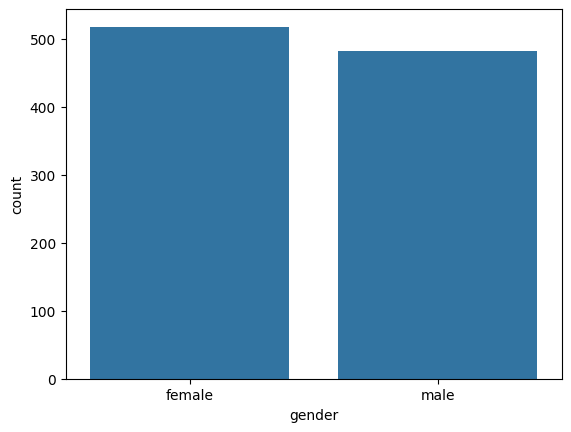

In [20]:
sns.countplot(x='gender', data=df)

In [21]:
print(df.describe)

<bound method NDFrame.describe of      gender gender.1            gender.2      gender.3   gender.4  gender.5  \
0    female  group B   bachelor's degree      standard       none        72   
1    female  group C        some college      standard  completed        69   
2    female  group B     master's degree      standard       none        90   
3      male  group A  associate's degree  free/reduced       none        47   
4      male  group C        some college      standard       none        76   
..      ...      ...                 ...           ...        ...       ...   
995  female  group E     master's degree      standard  completed        88   
996    male  group C         high school  free/reduced       none        62   
997  female  group C         high school  free/reduced  completed        59   
998  female  group D        some college      standard  completed        68   
999  female  group D        some college  free/reduced       none        77   

     gender.6  ge

In [22]:
print(df.skew)

<bound method DataFrame.skew of      gender gender.1            gender.2      gender.3   gender.4  gender.5  \
0    female  group B   bachelor's degree      standard       none        72   
1    female  group C        some college      standard  completed        69   
2    female  group B     master's degree      standard       none        90   
3      male  group A  associate's degree  free/reduced       none        47   
4      male  group C        some college      standard       none        76   
..      ...      ...                 ...           ...        ...       ...   
995  female  group E     master's degree      standard  completed        88   
996    male  group C         high school  free/reduced       none        62   
997  female  group C         high school  free/reduced  completed        59   
998  female  group D        some college      standard  completed        68   
999  female  group D        some college  free/reduced       none        77   

     gender.6  gend

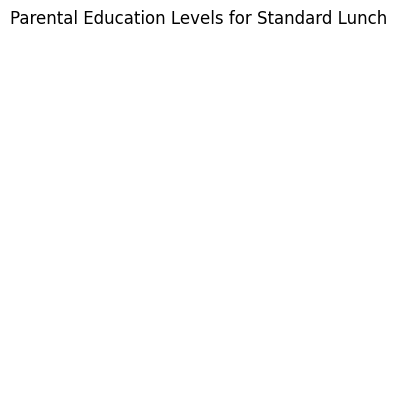

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('StudentsPerformance.csv')

# Filter for the 'lunch' category, assuming you want to analyze "standard" lunch
filtered_data = df[df['gender'] == 'standard']

# Group by parental level of education
grouped_data = filtered_data['gender.8'].value_counts()

# Create the pie chart for the 'lunch' category
plt.figure()
grouped_data.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('gender')
plt.ylabel('')  # Hide the y-label
plt.show()

In [41]:
race_gender_count = pd.crosstab(df['gender'], df['gender'])
print("\nMales and Females per Race Group:\n", race_gender_count)



Males and Females per Race Group:
 gender  female  male
gender              
female     518     0
male         0   482


In [43]:
lunch_gender_count = pd.crosstab(df['gender.1'], df['gender'])
print("\nLunch types by Gender:\n", lunch_gender_count)



Lunch types by Gender:
 gender    female  male
gender.1              
group A       36    53
group B      104    86
group C      180   139
group D      129   133
group E       69    71


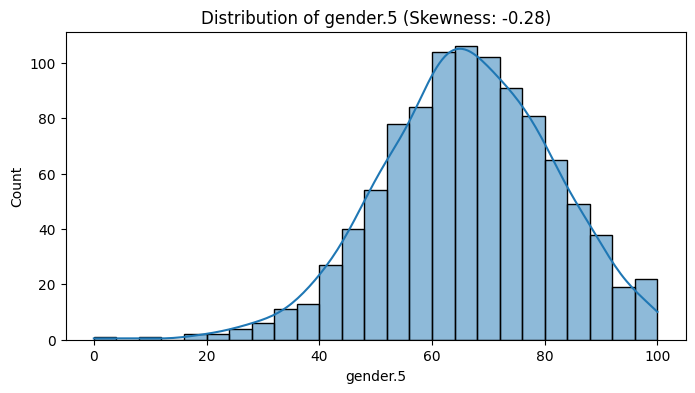

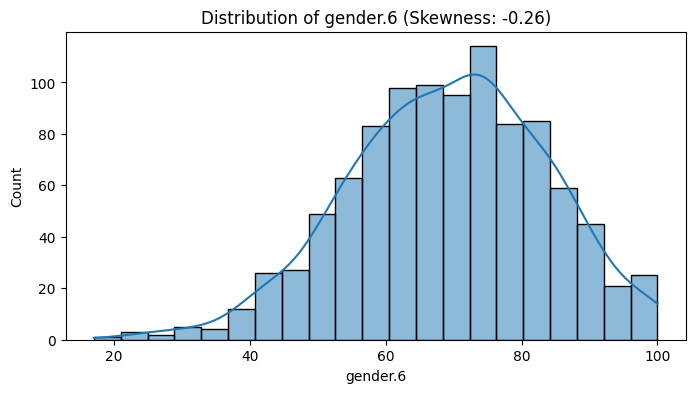

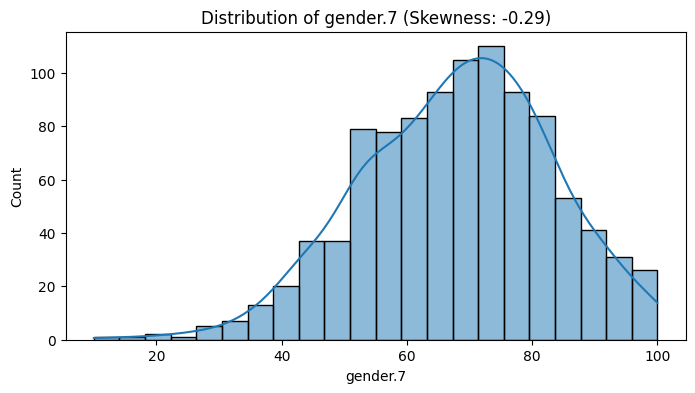

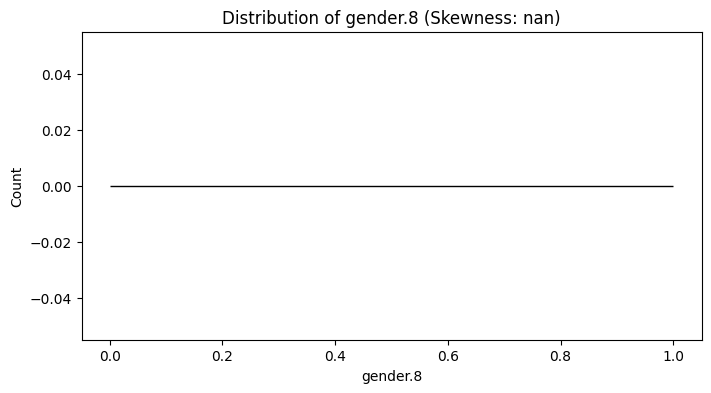

In [44]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col} (Skewness: {df[col].skew():.2f})')
    plt.show()


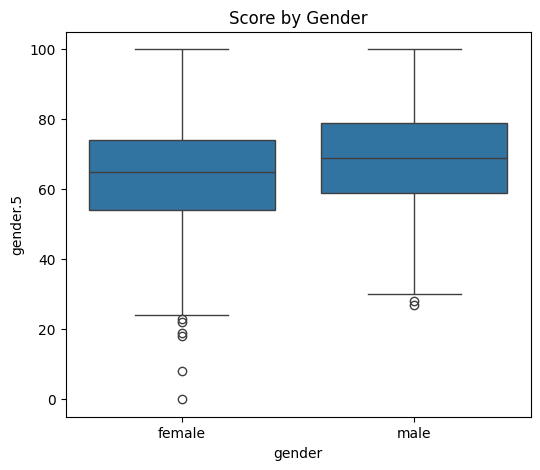

T-test p-value: 0.0000 (Significant if < 0.05)


In [51]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='gender', y='gender.5', data=df)
plt.title('Score by Gender')
plt.show()

# Optional: T-test to see if the difference is statistically significant
from scipy.stats import ttest_ind
male_scores = df[df['gender'] == 'male']['gender.5']
female_scores = df[df['gender'] == 'female']['gender.5']
t_stat, p_val = ttest_ind(male_scores, female_scores)
print(f"T-test p-value: {p_val:.4f} (Significant if < 0.05)")

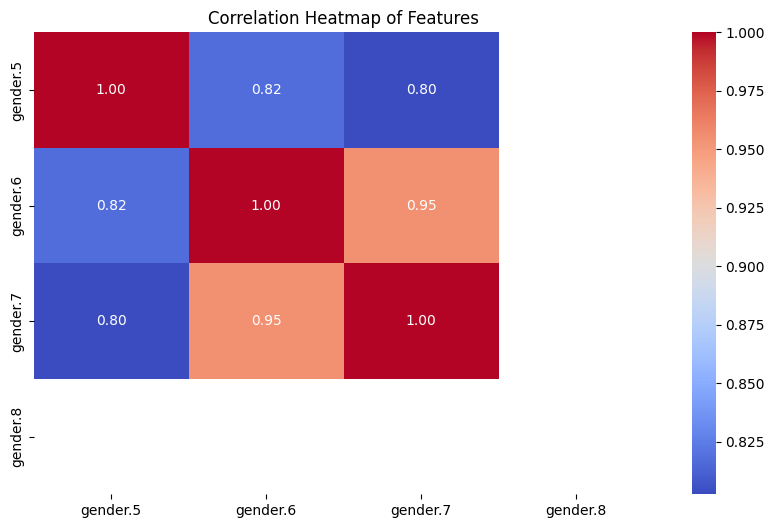

In [52]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()
